# 14 贪心算法

## 14.1 买卖股票的最佳时机

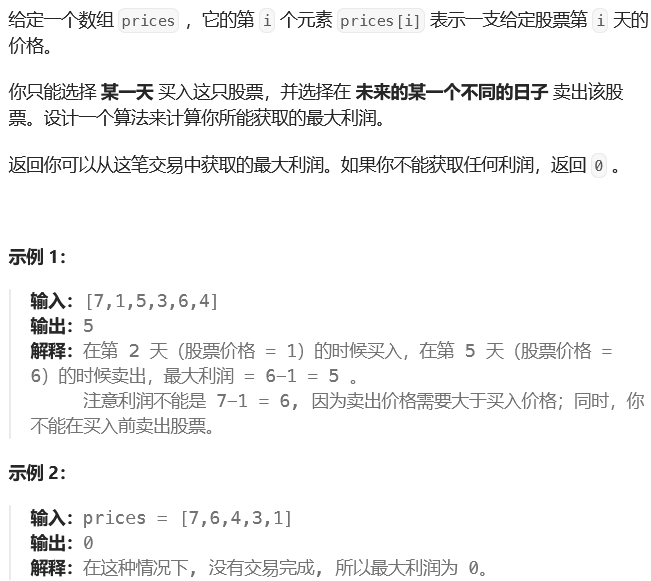

In [ ]:
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        min_price = prices[0]
        res = 0

        for price in prices[1:]:
            temp = price - min_price
            if temp > res:
                res = temp
            if min_price > price:
                min_price = price
        return res

## 14.2 跳跃游戏

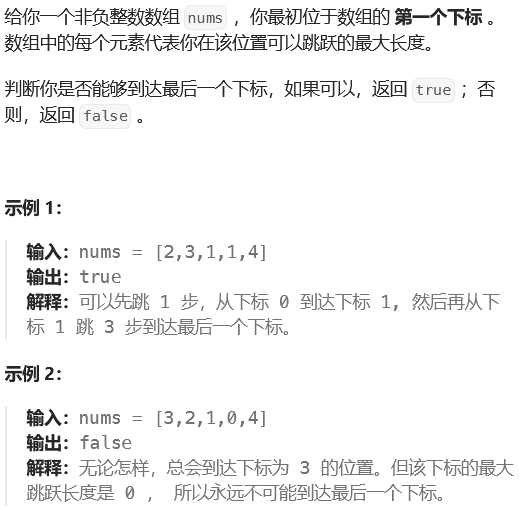

In [ ]:
class Solution:
    def canJump(self, nums: List[int]) -> bool:
        max_reach = 0
        n = len(nums)
        for i in range(n):
            # 当前位置超出最远可达，走不到这里
            if i > max_reach:
                return False
            # 更新最远能跳到哪
            max_reach = max(max_reach, i + nums[i])
            # 提前剪枝：已经能到最后一位
            if max_reach >= n - 1:
                return True
        return True

## 14.3 跳跃游戏 II

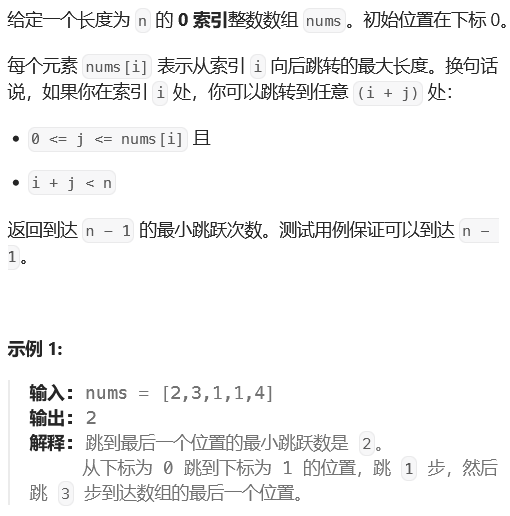

In [ ]:
class Solution:
    def jump(self, nums: List[int]) -> int:
        n = len(nums)
        if n == 1:
            return 0
        steps = 0
        cur_end = 0
        far = 0
        # 遍历到 n-2，最后一位不需要跳
        for i in range(n - 1):
            far = max(far, i + nums[i])
            # 走到当前区间尽头，必须起跳
            if i == cur_end:
                steps += 1
                cur_end = far
                # 提前终止：已经能到末尾
                if cur_end >= n - 1:
                    break
        return steps

## 14.4 划分字母区间

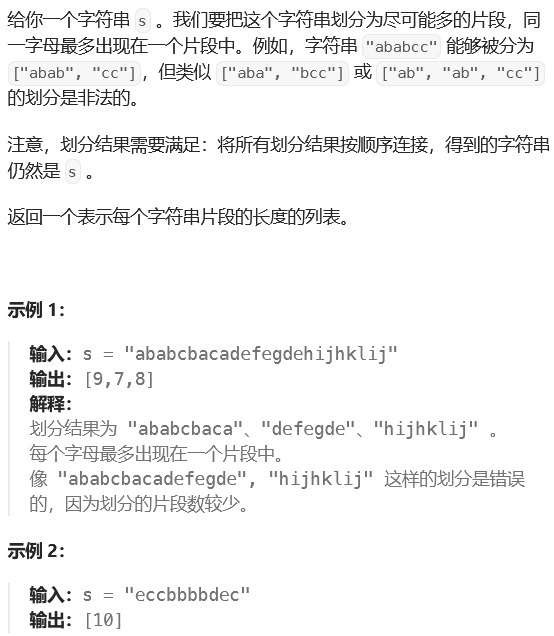

In [ ]:
class Solution:
    def partitionLabels(self, s: str) -> List[int]:
        # 1. 存储每个字母最后一次出现的索引
        last = {}
        for idx, c in enumerate(s):
            last[c] = idx
        
        res = []
        left = 0
        right = 0
        # 2. 遍历分割
        for i, c in enumerate(s):
            right = max(right, last[c])
            # 走到当前片段最右端，切割
            if i == right:
                res.append(i - left + 1)
                left = i + 1
        return res